### 1 Setup

#### Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# https://drive.google.com/uc?id=1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR
# !gdown 1bwRmKkPwmLKiqOgQ_LnKH0Vsc3mJKmVR

#### Dataset

In [3]:
df = pd.read_csv("data/cars24-car-price-cleaned.csv")
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,1.20,2012.0,120000,19.70,796.0,46.30,11.0,MARUTI,ALTO STD,1,0,0,0,0,1,1,1,0
1,5.50,2016.0,20000,18.90,1197.0,82.00,7.0,HYUNDAI,GRAND I10 ASTA,1,0,0,0,0,1,1,1,0
2,2.15,2010.0,60000,17.00,1197.0,80.00,13.0,HYUNDAI,I20 ASTA,1,0,0,0,0,1,1,1,0
3,2.26,2012.0,37000,20.92,998.0,67.10,11.0,MARUTI,ALTO K10 2010-2014 VXI,1,0,0,0,0,1,1,1,0
4,5.70,2015.0,30000,22.77,1498.0,98.59,8.0,FORD,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,0,0,1,0,0,0,1,1,0


#### Metadata

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19820 entries, 0 to 19819
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   selling_price     19820 non-null  float64
 1   year              19820 non-null  float64
 2   km_driven         19820 non-null  int64  
 3   mileage           19820 non-null  float64
 4   engine            19820 non-null  float64
 5   max_power         19820 non-null  float64
 6   age               19820 non-null  float64
 7   make              19820 non-null  str    
 8   model             19820 non-null  str    
 9   Individual        19820 non-null  int64  
 10  Trustmark Dealer  19820 non-null  int64  
 11  Diesel            19820 non-null  int64  
 12  Electric          19820 non-null  int64  
 13  LPG               19820 non-null  int64  
 14  Petrol            19820 non-null  int64  
 15  Manual            19820 non-null  int64  
 16  5                 19820 non-null  int64  
 17  >5  

In [5]:
df.isna().sum(axis=0)

selling_price       0
year                0
km_driven           0
mileage             0
engine              0
max_power           0
age                 0
make                0
model               0
Individual          0
Trustmark Dealer    0
Diesel              0
Electric            0
LPG                 0
Petrol              0
Manual              0
5                   0
>5                  0
dtype: int64

In [6]:
df.nunique().sort_values(ascending=False)

km_driven           4476
model               3233
selling_price        964
mileage              532
max_power            484
engine               167
make                  41
year                  27
age                   27
Individual             2
Trustmark Dealer       2
Diesel                 2
Electric               2
LPG                    2
Petrol                 2
Manual                 2
5                      2
>5                     2
dtype: int64

### 2 Encoding

#### Encoding Make

In [7]:
df["make_en"] = df.groupby("make")["selling_price"].transform("mean")
df[["make", "make_en"]].head()

,make,make_en
0,MARUTI,4.684721
1,HYUNDAI,5.458819
2,HYUNDAI,5.458819
3,MARUTI,4.684721
4,FORD,5.858258


#### Drop Make

In [8]:
df.drop(columns="make", inplace=True)

#### Encoding Model

In [9]:
df["model_en"] = df.groupby("model")["selling_price"].transform("mean")
df[["model", "model_en"]].head()

,model,model_en
0,ALTO STD,1.180000
1,GRAND I10 ASTA,4.818750
2,I20 ASTA,3.394000
3,ALTO K10 2010-2014 VXI,2.242676
4,ECOSPORT 2015-2021 1.5 TDCI TITANIUM BSIV,6.777576


#### Drop Model

In [10]:
df.drop(columns="model", inplace=True)

### 3 Scaling

#### Min-Max Scaler

In [11]:
scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5,make_en,model_en
0,0.043684,0.689655,0.031553,0.135345,0.117891,0.066506,0.310345,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.194048,0.041550
1,0.252397,0.827586,0.005237,0.128448,0.177281,0.123994,0.172414,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.232517,0.218382
2,0.089795,0.620690,0.015764,0.112069,0.177281,0.120773,0.379310,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.232517,0.149143
3,0.095134,0.689655,0.009711,0.145862,0.147808,0.100000,0.310345,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.194048,0.093193
4,0.262104,0.793103,0.007869,0.161810,0.221860,0.150709,0.206897,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.252367,0.313574


> **Note**:
> - Scaling the entire dataset is not a correct approach.
> - Scaling entire dataset leads to Data leakage between Train and Test set.

### 4 Training Setup

In [12]:
target = "selling_price"
X = df.drop(columns=target)
y = df[target]

X.shape, y.shape

((19820, 17), (19820,))

#### Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((13874, 17), (5946, 17), (13874,), (5946,))

In [14]:
X_train.head()

,year,km_driven,mileage,engine,max_power,age,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5,make_en,model_en
875,0.724138,0.018395,0.129397,0.216380,0.166586,0.275862,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.190168,0.238381
14801,0.827586,0.009184,0.103448,0.322719,0.217391,0.172414,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.324782,0.385102
15712,0.448276,0.013132,0.085345,0.236671,0.140097,0.551724,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.035781,0.057101
13806,0.931034,0.004447,0.128448,0.177281,0.123994,0.068966,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.232517,0.182254
8842,0.827586,0.008921,0.106724,0.296060,0.276973,0.172414,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.964468,1.000000


### 5 Uni-variate LR

In [15]:
X1 = X[["model_en"]]  # slicing - one input variable

X1_train = X_train[["model_en"]]
X1_test = X_test[["model_en"]]

In [16]:
model1 = LinearRegression()
model1.fit(X1_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['model_en']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.001301
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [17]:
model1.intercept_

np.float64(0.001300682918598861)

In [18]:
model1.coef_

array([0.99881913])

In [19]:
y_hat = model1.predict(X1)
y_hat

array([0.04280185, 0.21942453, 0.15026805, ..., 0.20171979, 0.37852554,
       0.520152  ], shape=(19820,))

#### Train Score

In [20]:
model1.score(X1_train, y_train)

0.9365772433664862

#### Test Score

In [21]:
model1.score(X1_test, y_test)

0.9384485838580185

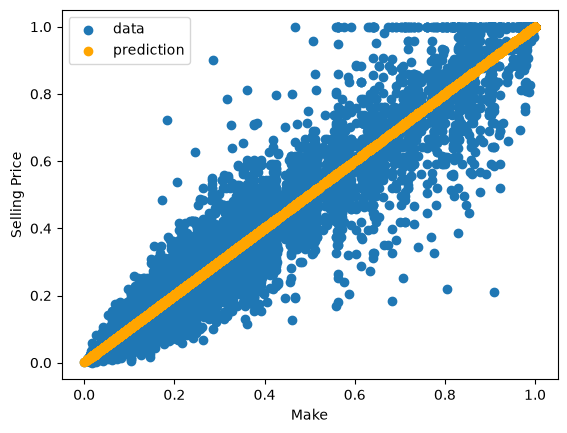

In [22]:
fig = plt.figure()

plt.scatter(X1, y, label="data")
plt.scatter(X1, y_hat, color="orange", label="prediction")
plt.xlabel("Make")
plt.ylabel("Selling Price")
plt.legend()

plt.show()

### 6 Multi-variate LR

In [23]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](17,)","[ 0.12,-0.56,-0.26,...,-0.02, 0.07, 0.86]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](17,)","['year','km_driven','mileage',...,'>5','make_en','model_en']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.002054
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,17
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)


In [24]:
model2.intercept_

np.float64(-0.0020544363848221114)

In [25]:
model2.coef_

array([ 0.12358025, -0.5640133 , -0.25897669,  0.08319302,  0.03142999,
       -0.12358025, -0.0062768 , -0.0105836 ,  0.00569622,  0.11686505,
        0.01498201, -0.00995931, -0.0048959 , -0.01238884, -0.02063572,
        0.06902383,  0.85733269])

In [26]:
y_hat_train = model2.predict(X_train)
y_hat_test = model2.predict(X_test)

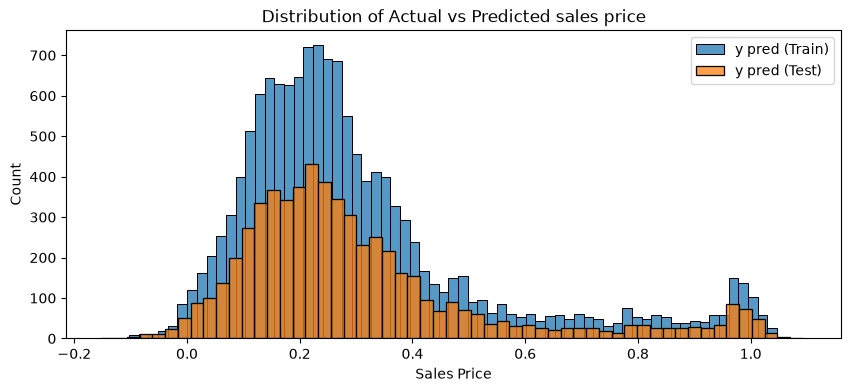

In [27]:
plt.figure(figsize=(10, 4))

sns.histplot(y_hat_train, label="y pred (Train)")
sns.histplot(y_hat_test, label="y pred (Test)")
plt.title("Distribution of Actual vs Predicted sales price")
plt.xlabel("Sales Price")
plt.legend()

plt.show()

#### Train Score

In [28]:
model2.score(X_train, y_train)

0.9457475156522621

#### Test Score

In [29]:
model2.score(X_test, y_test)

0.9454380064781047